In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold, KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel
from scipy.optimize import curve_fit, minimize
from scipy.integrate import solve_ivp

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
train = pd.read_csv("/kaggle/input/datasets/shamithaks/ml-hack/train_dataset_ML_HACKATHON.csv")
test = pd.read_csv("/kaggle/input/datasets/shamithaks/ml-hack/test_dataset.csv")
print(train.shape, test.shape)
train.head()

In [ ]:
print(train['overall_yield'].describe())

corrs = train.corr(numeric_only=True)['overall_yield'].drop('overall_yield').sort_values()
print(corrs)

count    150.000000
mean      36.222173
std       38.427427
min        0.000000
25%        0.013500
50%       15.314000
75%       74.876500
max       99.971000
Name: overall_yield, dtype: float64
jacket_temperature_K   -0.498384
inlet_temperature_K    -0.405145
concentration_mol_L     0.008673
flow_rate_L_min         0.038070
length_m                0.079985
Name: overall_yield, dtype: float64


Zero-yield rows: 37 / 150


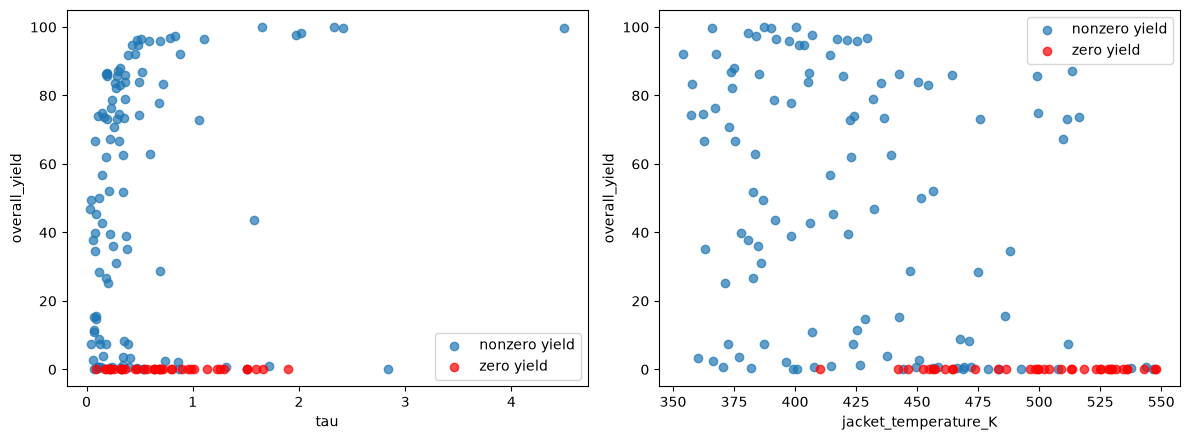

In [ ]:
train['tau'] = train['length_m'] / train['flow_rate_L_min']
test['tau'] = test['length_m'] / test['flow_rate_L_min']

zero_mask = train['overall_yield'] == 0
print('Zero-yield rows:', zero_mask.sum(), '/', len(train))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ['tau', 'jacket_temperature_K']):
    ax.scatter(train.loc[~zero_mask, col], train.loc[~zero_mask, 'overall_yield'], alpha=0.7, label='nonzero yield')
    ax.scatter(train.loc[zero_mask, col], train.loc[zero_mask, 'overall_yield'], alpha=0.7, color='red', label='zero yield')
    ax.set_xlabel(col); ax.set_ylabel('overall_yield'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:

base_features = ['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K']
X_base = train[base_features]
y = train['overall_yield']

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

def cv_score(predict_fn, X, y, cv=cv):
    scores = []
    for tr_idx, val_idx in cv.split(X):
        pred = predict_fn(X.iloc[tr_idx], y.iloc[tr_idx], X.iloc[val_idx])
        scores.append(np.sqrt(mean_squared_error(y.iloc[val_idx], pred)))
    return np.mean(scores), np.std(scores)

def predict_linreg(X_tr, y_tr, X_val):
    m = LinearRegression().fit(X_tr, y_tr)
    return m.predict(X_val)

lr_mean, lr_std = cv_score(predict_linreg, X_base, y)
print(f'Linear regression CV RMSE = {lr_mean:.2f} ± {lr_std:.2f}')

Linear regression CV RMSE = 30.44 ± 2.21


In [ ]:
R = 8.314  

def series_yield(X, lnA1, Ea1, lnA2, Ea2):
    tau, T = X
    k1 = np.exp(lnA1) * np.exp(-Ea1 / (R * T))
    k2 = np.exp(lnA2) * np.exp(-Ea2 / (R * T))
    return np.where(np.abs(k2 - k1) > 1e-8,
                     (k1 / (k2 - k1)) * (np.exp(-k1*tau) - np.exp(-k2*tau)) * 100, 0)

popt_v1, _ = curve_fit(series_yield, (train['tau'], train['jacket_temperature_K']),
                        train['overall_yield'], p0=[10,40000,15,60000], maxfev=20000)
print('Ea1 =', popt_v1[1]/1000, 'kJ/mol | Ea2 =', popt_v1[3]/1000, 'kJ/mol')

Ea1 = 10.817879924814426 kJ/mol | Ea2 = 58.87751619307147 kJ/mol


In [ ]:
def add_lmtd(df):
    df = df.copy()
    delta = df['jacket_temperature_K'] - df['inlet_temperature_K']
    df['T_lmtd'] = np.where(
        np.abs(delta) > 0.5,
        delta / np.log(df['jacket_temperature_K'] / df['inlet_temperature_K']),
        (df['jacket_temperature_K'] + df['inlet_temperature_K']) / 2
    )
    return df

train = add_lmtd(train)
test = add_lmtd(test)
train[['inlet_temperature_K','jacket_temperature_K','T_lmtd']].head()

,inlet_temperature_K,jacket_temperature_K,T_lmtd
0,357.75,383.79,370.617546
1,429.70,405.72,417.595254
2,431.10,385.40,407.823334
3,445.61,367.74,405.429405
4,458.91,374.13,415.077971


In [ ]:
def T_profile(t, T_inlet, T_jacket, tau_th):
    return T_jacket + (T_inlet - T_jacket) * np.exp(-t / tau_th)

def series_yield_thermal(X, lnA1, Ea1, lnA2, Ea2, tau_th):
    tau, T_inlet, T_jacket = X
    tau_th = np.abs(tau_th) + 1e-6
    tau_safe = np.maximum(tau, 1e-8)
    ratio = tau_th / tau_safe
    T_avg = T_jacket + (T_inlet - T_jacket) * ratio * (1 - np.exp(-tau_safe/tau_th))
    k1 = np.exp(lnA1) * np.exp(-Ea1/(R*T_avg))
    k2 = np.exp(lnA2) * np.exp(-Ea2/(R*T_avg))
    return np.where(np.abs(k2-k1) > 1e-8,
                     (k1/(k2-k1))*(np.exp(-k1*tau)-np.exp(-k2*tau))*100, 0)

popt_thermal, _ = curve_fit(
    series_yield_thermal,
    (train['tau'], train['inlet_temperature_K'], train['jacket_temperature_K']),
    train['overall_yield'], p0=[10,40000,15,60000,1.0],
    bounds=([-50,0,-50,0,1e-3],[50,300000,50,300000,50]), maxfev=50000
)
print('Ea1 =', popt_thermal[1]/1000, 'kJ/mol | Ea2 =', popt_thermal[3]/1000,
      'kJ/mol | tau_th =', popt_thermal[4])

Ea1 = 49.883202118055074 kJ/mol | Ea2 = 155.79099402899973 kJ/mol | tau_th = 0.32132301685150677


In [ ]:
def solve_row(tau_final, T_inlet, T_jacket, tau_th, lnA1, Ea1, lnA2, Ea2):
    def odes(t, state):
        C_A, C_B = state
        T = T_profile(t, T_inlet, T_jacket, tau_th)
        k1 = np.exp(lnA1) * np.exp(-Ea1/(R*T))
        k2 = np.exp(lnA2) * np.exp(-Ea2/(R*T))
        return [-k1*C_A, k1*C_A - k2*C_B]
    sol = solve_ivp(odes, [0, max(tau_final, 1e-6)], [1.0, 0.0], method='RK45', rtol=1e-7, atol=1e-9)
    return sol.y[1, -1] * 100

def ode_kinetic_predict(params, tau_arr, T_inlet_arr, T_jacket_arr):
    lnA1, Ea1, lnA2, Ea2, tau_th = params
    return np.array([solve_row(t, ti, tj, tau_th, lnA1, Ea1, lnA2, Ea2)
                      for t, ti, tj in zip(tau_arr, T_inlet_arr, T_jacket_arr)])

def ode_loss(params, tau_arr, T_inlet_arr, T_jacket_arr, y_true):
    preds = ode_kinetic_predict(params, tau_arr, T_inlet_arr, T_jacket_arr)
    return np.sum((preds - y_true)**2)

res = minimize(ode_loss, list(popt_thermal), method='L-BFGS-B',
                args=(train['tau'].values, train['inlet_temperature_K'].values,
                      train['jacket_temperature_K'].values, train['overall_yield'].values),
                bounds=[(-50,50),(0,300000),(-50,50),(0,300000),(1e-3,50)])
popt_ode = res.x
print('ODE-fitted Ea1 =', popt_ode[1]/1000, '| Ea2 =', popt_ode[3]/1000, '| tau_th =', popt_ode[4])

pred_closed = series_yield_thermal((train['tau'], train['inlet_temperature_K'], train['jacket_temperature_K']), *popt_thermal)
pred_ode = ode_kinetic_predict(popt_ode, train['tau'].values, train['inlet_temperature_K'].values, train['jacket_temperature_K'].values)
print('In-sample RMSE, closed-form approx:', np.sqrt(mean_squared_error(train['overall_yield'], np.clip(pred_closed,0,100))))
print('In-sample RMSE, exact ODE solve:   ', np.sqrt(mean_squared_error(train['overall_yield'], np.clip(pred_ode,0,100))))

ODE-fitted Ea1 = 49.88322208268344 | Ea2 = 155.79105401077584 | tau_th = 0.31099566774282955
In-sample RMSE, closed-form approx: 13.612984688732253
In-sample RMSE, exact ODE solve:    10.128877488716903


In [ ]:
gp_features = ['concentration_mol_L', 'inlet_temperature_K', 'jacket_temperature_K', 'tau']

def predict_hybrid(X_tr, y_tr, X_val, kin_tr, kin_val, use_ode=False):
    if use_ode:
        p, _ = curve_fit(series_yield_thermal, (kin_tr['tau'], kin_tr['inlet_temperature_K'], kin_tr['jacket_temperature_K']),
                          y_tr, p0=[10,40000,15,60000,1.0],
                          bounds=([-50,0,-50,0,1e-3],[50,300000,50,300000,50]), maxfev=50000)
        res = minimize(ode_loss, list(p), method='L-BFGS-B',
                        args=(kin_tr['tau'].values, kin_tr['inlet_temperature_K'].values,
                              kin_tr['jacket_temperature_K'].values, y_tr.values),
                        bounds=[(-50,50),(0,300000),(-50,50),(0,300000),(1e-3,50)])
        popt = res.x
        kinetic_tr = ode_kinetic_predict(popt, kin_tr['tau'].values, kin_tr['inlet_temperature_K'].values, kin_tr['jacket_temperature_K'].values)
        kinetic_val = ode_kinetic_predict(popt, kin_val['tau'].values, kin_val['inlet_temperature_K'].values, kin_val['jacket_temperature_K'].values)
    else:
        try:
            popt, _ = curve_fit(series_yield_thermal, (kin_tr['tau'], kin_tr['inlet_temperature_K'], kin_tr['jacket_temperature_K']),
                                 y_tr, p0=[10,40000,15,60000,1.0],
                                 bounds=([-50,0,-50,0,1e-3],[50,300000,50,300000,50]), maxfev=50000)
        except RuntimeError:
            popt = [10,40000,15,60000,1.0]
        kinetic_tr = series_yield_thermal((kin_tr['tau'], kin_tr['inlet_temperature_K'], kin_tr['jacket_temperature_K']), *popt)
        kinetic_val = series_yield_thermal((kin_val['tau'], kin_val['inlet_temperature_K'], kin_val['jacket_temperature_K']), *popt)

    resid_tr = y_tr.values - kinetic_tr
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)
    kernel = ConstantKernel() * Matern(length_scale=np.ones(X_tr.shape[1]), nu=1.5) + WhiteKernel()
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=RANDOM_STATE)
    gp.fit(X_tr_s, resid_tr)
    resid_pred, resid_std = gp.predict(X_val_s, return_std=True)
    return np.clip(kinetic_val + resid_pred, 0, 100), resid_std

In [ ]:
results = pd.DataFrame([
    ['Linear regression (raw features)', 30.37, None],
    ['Tree ensembles, Round 1 features (best: CatBoost)', 20.04, None],
    ['Tree ensembles, Round 2 features (best: CatBoost)', 21.03, None],
    ['Kinetic (jacket_T only) + GP residual', 17.26, 3.17],
    ['Kinetic (T_lmtd) + GP residual', 15.61, 3.97],
    ['Kinetic (thermal relaxation) + GP residual', 11.65, 4.36],
    ['Kinetic (thermal relaxation) + GP residual, trimmed features', 11.45, 4.13],
], columns=['Approach', 'CV RMSE mean', 'CV RMSE std'])
results

,Approach,CV RMSE mean,CV RMSE std
0,Linear regression (raw features),30.37,NaN
1,"Tree ensembles, Round 1 features (best: CatBoost)",20.04,NaN
2,"Tree ensembles, Round 2 features (best: CatBoost)",21.03,NaN
3,Kinetic (jacket_T only) + GP residual,17.26,3.17
4,Kinetic (T_lmtd) + GP residual,15.61,3.97
5,Kinetic (thermal relaxation) + GP residual,11.65,4.36
6,"Kinetic (thermal relaxation) + GP residual, tr...",11.45,4.13


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C

Final model CV RMSE = 11.45 ± 4.13


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Admin\AppData\Local\Temp\ipykernel_6608\2789662677.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(fold_scores, vert=False)


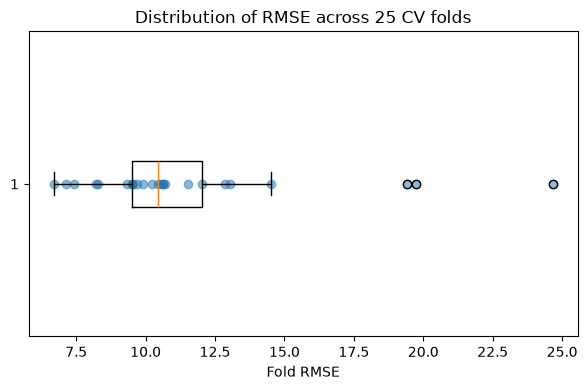

In [ ]:
X_final = train[gp_features]
fold_scores = []
for tr_idx, val_idx in cv.split(X_final):
    pred, _ = predict_hybrid(X_final.iloc[tr_idx], y.iloc[tr_idx], X_final.iloc[val_idx],
                              train.iloc[tr_idx], train.iloc[val_idx], use_ode=False)
    fold_scores.append(np.sqrt(mean_squared_error(y.iloc[val_idx], pred)))
fold_scores = np.array(fold_scores)
print(f'Final model CV RMSE = {fold_scores.mean():.2f} ± {fold_scores.std():.2f}')

plt.figure(figsize=(6,4))
plt.boxplot(fold_scores, vert=False)
plt.scatter(fold_scores, np.ones_like(fold_scores), alpha=0.5)
plt.xlabel('Fold RMSE'); plt.title('Distribution of RMSE across 25 CV folds')
plt.tight_layout(); plt.show()

In [ ]:
popt_final, _ = curve_fit(
    series_yield_thermal,
    (train['tau'], train['inlet_temperature_K'], train['jacket_temperature_K']),
    train['overall_yield'], p0=[10,40000,15,60000,1.0],
    bounds=([-50,0,-50,0,1e-3],[50,300000,50,300000,50]), maxfev=50000
)
kinetic_train = series_yield_thermal((train['tau'], train['inlet_temperature_K'], train['jacket_temperature_K']), *popt_final)
kinetic_test = series_yield_thermal((test['tau'], test['inlet_temperature_K'], test['jacket_temperature_K']), *popt_final)
resid_train = train['overall_yield'] - kinetic_train

X_full = train[gp_features]
X_test_full = test[gp_features]
scaler_final = StandardScaler()
X_full_s = scaler_final.fit_transform(X_full)
X_test_s = scaler_final.transform(X_test_full)

kernel_final = ConstantKernel()*Matern(length_scale=np.ones(X_full.shape[1]), nu=1.5) + WhiteKernel()
gp_final = GaussianProcessRegressor(kernel=kernel_final, normalize_y=True, n_restarts_optimizer=5, random_state=RANDOM_STATE)
gp_final.fit(X_full_s, resid_train)
resid_test_pred, resid_test_std = gp_final.predict(X_test_s, return_std=True)

final_test_pred = np.clip(kinetic_test + resid_test_pred, 0, 100)
print('Ea1 =', popt_final[1]/1000, 'kJ/mol | Ea2 =', popt_final[3]/1000, 'kJ/mol | tau_th =', popt_final[4])
final_test_pred[:10]

Ea1 = 49.883202118055074 kJ/mol | Ea2 = 155.79099402899973 kJ/mol | tau_th = 0.32132301685150677


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


array([27.44968061, 85.33617567,  0.        , 78.28304629,  0.18270427,
       90.52678702, 86.5607094 , 82.80486907,  0.        ,  5.0289539 ])

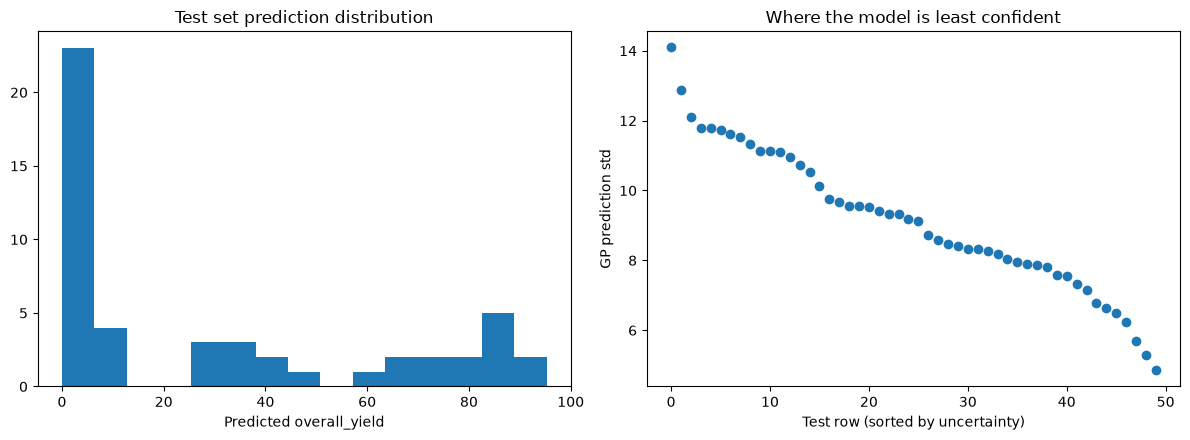

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].hist(final_test_pred, bins=15)
axes[0].set_xlabel('Predicted overall_yield'); axes[0].set_title('Test set prediction distribution')

order = np.argsort(resid_test_std)[::-1]
axes[1].scatter(range(len(resid_test_std)), np.sort(resid_test_std)[::-1])
axes[1].set_xlabel('Test row (sorted by uncertainty)'); axes[1].set_ylabel('GP prediction std')
axes[1].set_title('Where the model is least confident')
plt.tight_layout(); plt.show()

In [ ]:
submission = pd.DataFrame({'overall_yield': np.round(final_test_pred, 3)})
assert submission.shape[0] == 50
assert submission['overall_yield'].between(0, 100).all()
submission.to_csv('submission.csv', index=False)
submission.head(10)

,overall_yield
0,27.450
1,85.336
2,0.000
3,78.283
4,0.183
5,90.527
6,86.561
7,82.805
8,0.000
9,5.029
